In [1]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Load CO2 data from Statsmodels' built-in dataset library
# This dataset contains weekly measurements of CO2 concentrations
data = sm.datasets.co2.load_pandas().data

# Display the DataFrame to see its structure and first few rows
data


,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4
...,...
2001-12-01,370.3
2001-12-08,370.8
2001-12-15,371.2
2001-12-22,371.3


In [3]:
# Check for any missing values
data.isna().sum()

co2    59
dtype: int64

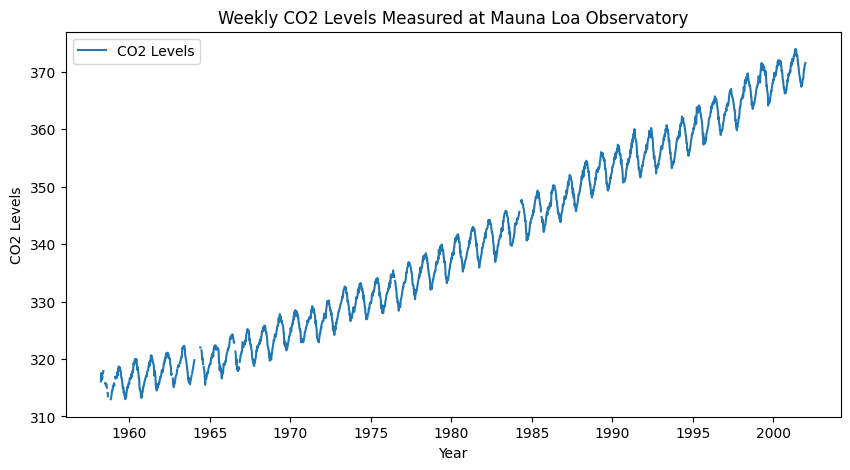

In [4]:
# Plot the data to visualize trends
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['co2'], label='CO2 Levels')
plt.title('Weekly CO2 Levels Measured at Mauna Loa Observatory')
plt.xlabel('Year')
plt.ylabel('CO2 Levels')
plt.legend()
plt.show()

/var/folders/vl/z6gfc_1s4mbd9k5knjb6qm1c0000gn/T/ipykernel_96640/2511311622.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['filled'] = data['co2'].fillna(method='ffill')


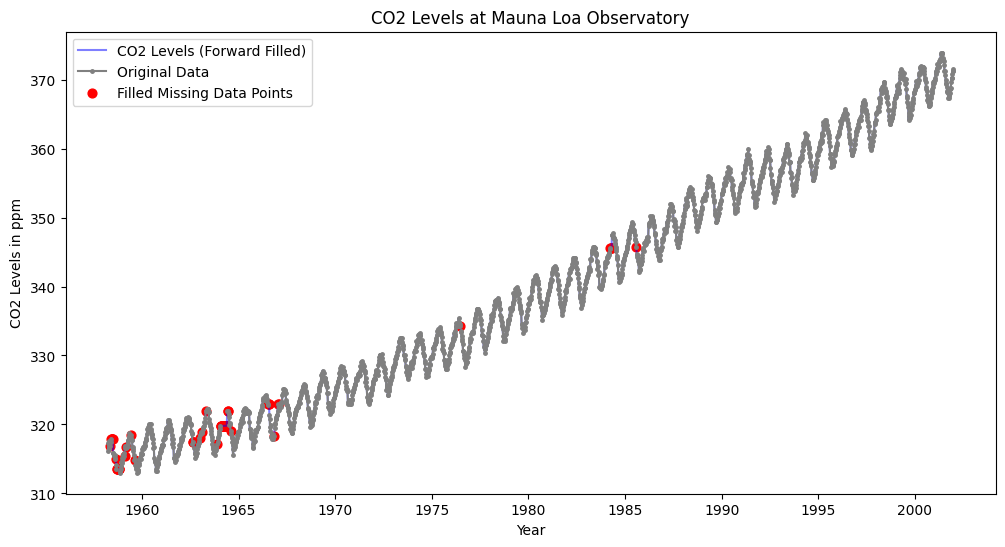

In [5]:
# Identify NaN values in the CO2 data column
missing = data['co2'].isna()

# Forward fill missing values in the CO2 data and create a new column for comparison
data['filled'] = data['co2'].fillna(method='ffill')

# Set up a plot with specified dimensions
plt.figure(figsize=(12, 6))

# Plot the forward-filled data with reduced opacity for clarity
plt.plot(data.index, data['filled'], label='CO2 Levels (Forward Filled)', color='blue', alpha=0.5)

# Plot the original data using a line and dot marker for each data point
plt.plot(data.index, data['co2'], linestyle='-', marker='.', label='Original Data', color='gray', markersize=5)

# Highlight where the missing values were filled, using red scatter points
plt.scatter(data.index[missing], data['filled'][missing], color='red', s=40, label='Filled Missing Data Points')

# Add a title and labels to the plot
plt.title('CO2 Levels at Mauna Loa Observatory')
plt.xlabel('Year')
plt.ylabel('CO2 Levels in ppm')

# Include a legend to identify the plotted series
plt.legend()

# Display the plot
plt.show()


In [6]:
data.fillna(method='ffill', inplace=True)  # Forward-fill to handle missing values
data.drop(["filled"],axis=1, inplace=True)

data.isna().sum()

/var/folders/vl/z6gfc_1s4mbd9k5knjb6qm1c0000gn/T/ipykernel_96640/2526172522.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)  # Forward-fill to handle missing values


co2    0
dtype: int64

## Seasonal Decomposition for Trend, seasonal and residual analysis

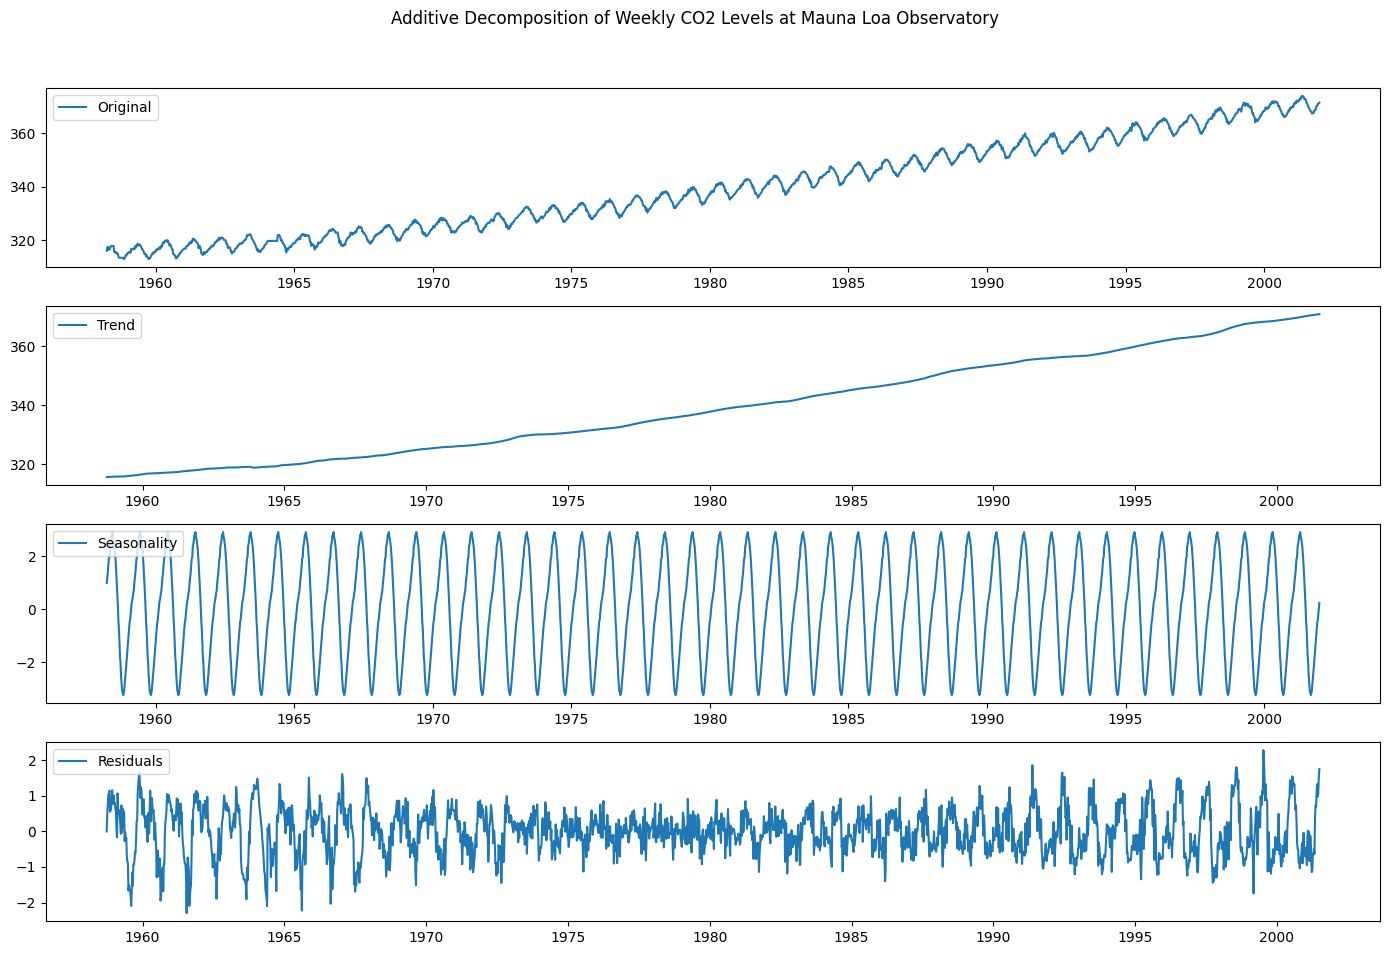

In [7]:
# Ensure the time series index is set properly as a DatetimeIndex
if not isinstance(data.index, pd.DatetimeIndex):
    data.index = pd.to_datetime(data.index)

# Ensure that the DataFrame is sorted by date for consistent analysis
data.sort_index(inplace=True)

# Perform seasonal decomposition of weekly CO2 data with a period of one year (52 weeks)
decomposition = sm.tsa.seasonal_decompose(data['co2'], model='additive', period=52)

# Extracting the trend component from the decomposition
trend = decomposition.trend

# Extracting the seasonal component from the decomposition
seasonal = decomposition.seasonal

# Extracting the residual component from the decomposition
residual = decomposition.resid

# Set up a figure for plotting the original and decomposed components
fig = plt.figure(figsize=(14, 10))

# Plot the original CO2 data
plt.subplot(411)
plt.plot(data.co2, label='Original')
plt.legend(loc='upper left')

# Plot the extracted trend component
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='upper left')

# Plot the extracted seasonal component
plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='upper left')

# Plot the extracted residuals
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='upper left')

# Add a title to the figure and adjust layout for better visibility
fig.suptitle('Additive Decomposition of Weekly CO2 Levels at Mauna Loa Observatory')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Seasonal Decomposition of CO2 Data

### Overview
This performs a seasonal decomposition of the CO2 concentrations measured weekly at the Mauna Loa Observatory to identify underlying trend, seasonal patterns, and irregular components.

### Detailed Code Breakdown

- **Datetime Index Check and Conversion:**
  - `if not isinstance(data.index, pd.DatetimeIndex):`
    - Checks if the index of `data` is already a `DatetimeIndex`. If not, it converts the index to `DatetimeIndex` to ensure proper time series manipulation.
  - `data.index = pd.to_datetime(data.index)`
    - Converts the index to `DatetimeIndex`, enabling time-based indexing and operations essential for time series analysis.

- **Sorting Data:**
  - `data.sort_index(inplace=True)`
    - Sorts the DataFrame by the index (date) in place to ensure chronological order, which is crucial for time series analysis to avoid potential misalignment in patterns and computations.

- **Seasonal Decomposition:**
  - `decomposition = sm.tsa.seasonal_decompose(data['co2'], model='additive', period=52)`
    - Decomposes the CO2 time series into trend, seasonal, and residual components using an additive model where the period is set to 52 weeks, reflecting one year of data.

- **Component Extraction:**
  - `trend = decomposition.trend`
    - Extracts the trend component, showing long-term progression of CO2 levels.
  - `seasonal = decomposition.seasonal`
    - Extracts the seasonal component, showing repeating short-term cycle within a year.
  - `residual = decomposition.resid`
    - Extracts the residual component, representing the irregularities not explained by trend or seasonality.

This analysis is essential for understanding the behavioral components of CO2 levels over time, particularly useful in climatology and environmental science to assess trends and seasonality for future forecasting and policy-making.

## Augmented Dickey-Fuller test

In [8]:
# Import the Augmented Dickey-Fuller test function from statsmodels
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller test to check for stationarity
# The test is performed on the 'co2' column of the data, with NaN values dropped to ensure accurate results
adf_result = adfuller(data['co2'].dropna())

# Print the ADF test statistic
print('ADF Statistic: %f' % adf_result[0])

# Print the p-value of the ADF test
print('p-value: %f' % adf_result[1])

# Print the critical values of the test for different significance levels
print('Critical Values:')
for key, value in adf_result[4].items():
    print('\t%s: %.3f' % (key, value))


ADF Statistic: 0.046051
p-value: 0.962179
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567


## Performing Augmented Dickey-Fuller Test on CO2 Data

### Overview
The conducts the Augmented Dickey-Fuller (ADF) test on CO2 levels data to determine if the series is stationary, which is critical for many types of time series analysis, particularly when modeling.

### Detailed Code Breakdown

- **Importing the ADF Function:**
  - `from statsmodels.tsa.stattools import adfuller`: Imports the `adfuller` function from the `statsmodels` library, which is used to perform the Augmented Dickey-Fuller test, a type of statistical test called a unit root test.

- **Performing the ADF Test:**
  - `adf_result = adfuller(data['co2'].dropna())`: Executes the ADF test on the CO2 data after removing any NaN values with `dropna()`. This is necessary because the ADF test requires there to be no missing values in the series.

- **Printing Test Results:**
  - `print('ADF Statistic: %f' % adf_result[0])`: Prints the ADF statistic, a negative number closer to zero suggests less likelihood of a unit root (non-stationarity).
  - `print('p-value: %f' % adf_result[1])`: Prints the p-value which indicates the probability that the series has a unit root. A low p-value (typically < 0.05) suggests
  

## ADF Test
- 'Unit Root Test’, which is the proper method for testing the stationarity of a time series.
- p value > 0.05: Accepts the Null Hypothesis (H0), the data has a unit root and is non-stationary.
 - p value < = 0.05: Rejects the Null Hypothesis (H0), the data is stationary.


## KPSS test

In [9]:
# Import the KPSS test function from statsmodels
from statsmodels.tsa.stattools import kpss

# Perform the KPSS test to check for stationarity
# The test is performed on the 'co2' column of the data, with NaN values dropped to ensure accurate results
kpss_result = kpss(data['co2'].dropna(), regression='c')

# Print the KPSS test statistic
print('KPSS Statistic: %f' % kpss_result[0])

# Print the p-value of the KPSS test
print('p-value: %f' % kpss_result[1])

# Print the critical values of the test for different significance levels
print('Critical Values:')
for key, value in kpss_result[3].items():
    print('\t%s: %.3f' % (key, value))


KPSS Statistic: 7.649196
p-value: 0.010000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


/var/folders/vl/z6gfc_1s4mbd9k5knjb6qm1c0000gn/T/ipykernel_96640/230488612.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(data['co2'].dropna(), regression='c')


## Performing Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test on CO2 Data

### Overview
This conducts the KPSS test on CO2 levels data to determine if the series is stationary around a deterministic trend, which is critical for time series analysis where trend stationarity is to be assessed.

### Detailed Code Breakdown

- **Importing the KPSS Function:**
  - `from statsmodels.tsa.stattools import kpss`: Imports the `kpss` function from the `statsmodels` library, which is used to perform the KPSS test, a type of statistical test that checks for stationarity around a deterministic trend.

- **Performing the KPSS Test:**
  - `kpss_result = kpss(data['co2'].dropna(), regression='c')`: Executes the KPSS test on the CO2 data after removing any NaN values with `dropna()`. The parameter `'c'` indicates that the series is tested against a constant (no trend).

- **Printing Test Results:**
  - `print('KPSS Statistic: %f' % kpss_result[0])`: Prints the KPSS statistic, where a low value suggests stationarity.
  - `print('p-value: %f' % kpss_result[1])`: Prints the p-value which indicates the probability that the series is stationary around a deterministic trend. A high p-value (> 0.05) usually indicates failure to reject the hypothesis of stationarity.
  - `print('Critical Values:')`: Begins output for critical values associated with the test which are thresholds that the KPSS test statistic must not exceed to accept the null hypothesis of stationarity at various confidence levels.
  - `for key, value in kpss_result[3].items():`: Iterates over the dictionary of test critical values, printing each one. These values represent the cutoff points for the test statistic at the 1%, 5%, and 10% significance levels.

### Usage
The KPSS test is essential for understanding whether a time series is stationary around a deterministic trend, which has implications for choosing appropriate models for analysis and forecasting.

## KPSS Test
- 'Unit Root Test’, which is the proper method for testing the stationarity of a time series.
- If the p-value obtained should be greater than the significance level (say 0.05) in order to not reject the null hypothesis => then stationary


Differencing Level: 1
ADF Statistic: -15.517472
ADF p-value: 0.000000
KPSS Statistic: 0.018461
KPSS p-value: 0.100000


/var/folders/vl/z6gfc_1s4mbd9k5knjb6qm1c0000gn/T/ipykernel_96640/2496703885.py:45: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)
/var/folders/vl/z6gfc_1s4mbd9k5knjb6qm1c0000gn/T/ipykernel_96640/2496703885.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(diff_series, regression='c')


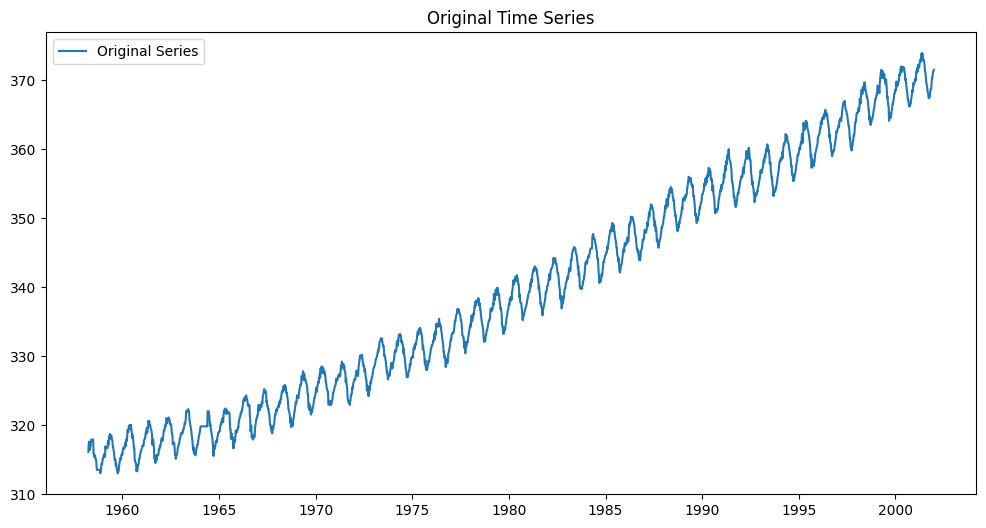

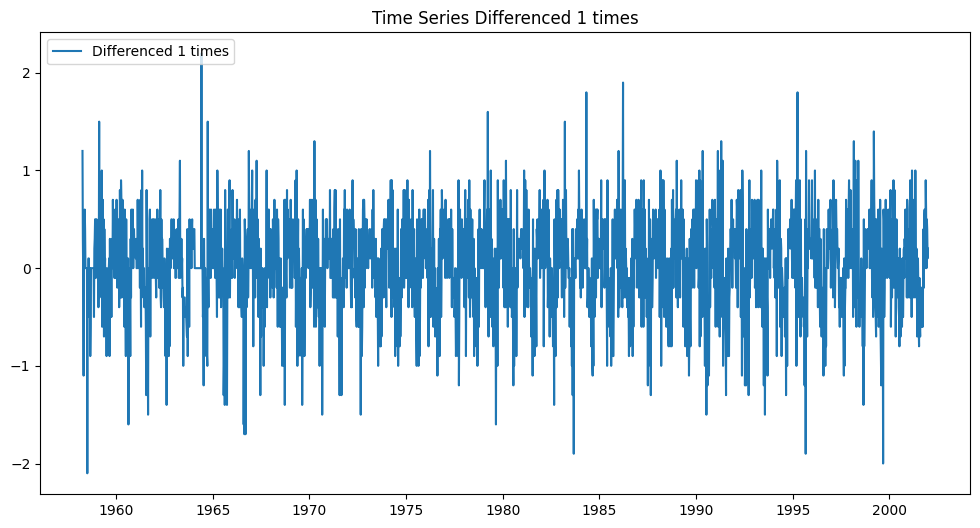

Stationarity achieved with differencing level: 1


In [10]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

def test_stationarity(timeseries, max_diff=10):
    # Plot the original series to provide a visual reference for the original data
    plt.figure(figsize=(12, 6))
    plt.plot(timeseries, label='Original Series')
    plt.title('Original Time Series')
    plt.legend(loc='upper left')
    
    # Loop through potential differencing levels to achieve stationarity
    for d in range(1, max_diff + 1):
        # Difference the series according to the current level d
        diff_series = timeseries.diff(d).dropna()

        # Conduct the Augmented Dickey-Fuller test on the differenced series
        adf_test = adfuller(diff_series)
        # Conduct the KPSS test on the differenced series
        kpss_test = kpss(diff_series, regression='c')

        # Output the results of the tests at each differencing level
        print(f'\nDifferencing Level: {d}')
        print('ADF Statistic: %f' % adf_test[0])
        print('ADF p-value: %f' % adf_test[1])
        print('KPSS Statistic: %f' % kpss_test[0])
        print('KPSS p-value: %f' % kpss_test[1])

        # Plot the differenced series to visualize changes
        plt.figure(figsize=(12, 6))
        plt.plot(diff_series, label=f'Differenced {d} times')
        plt.title(f'Time Series Differenced {d} times')
        plt.legend(loc='upper left')
        plt.show()

        # Stop if the series is considered stationary by both tests
        if adf_test[1] < 0.05 and kpss_test[1] > 0.05:
            print(f'Stationarity achieved with differencing level: {d}')
            break
        elif d == max_diff:
            print('Stationarity not achieved. Try increasing max_diff.')

# Load the dataset
data = sm.datasets.co2.load_pandas().data
data.fillna(method='ffill', inplace=True)

# Test for stationarity on the CO2 dataset
test_stationarity(data['co2'])


## Iterative Stationarity Testing of Time Series Data

### Purpose
This  tests for stationarity in a time series dataset using both the Augmented Dickey-Fuller (ADF) and KPSS tests. It employs iterative differencing to achieve stationarity, crucial for accurate time series modeling and forecasting.

### Detailed Code Explanation

#### Function Definition
- **Function `test_stationarity`**: Designed to perform stationarity tests on a time series with iterative differencing.
  - `timeseries`: The time series data to be tested.
  - `max_diff`: Maximum number of differencing steps to attempt.

#### Differencing and Testing Loop
- **Loop `for d in range(1, max_diff + 1)`**: Iterates through possible differencing levels.
  - `diff_series = timeseries.diff(d).dropna()`: Differences the series at level `d` and removes NaN values resulting from differencing.
  - **ADF and KPSS Tests**:
    - `adf_test = adfuller(diff_series)`: Performs the ADF test.
    - `kpss_test = kpss(diff_series, regression='c')`: Performs the KPSS test.
  - **Test Result Output**:
    - Prints ADF and KPSS statistics and p-values.
  - **Plotting Differenced Series**:
    - `plt.plot(diff_series, label=f'Differenced {d} times')`: Plots the differenced series.
    - `plt.title(f'Time Series Differenced {d} times')`: Adds a title to the plot of the differenced series.
    - `plt.legend(loc='upper left')`: Adds a legend.
    - `plt.show()`: Displays the plot.

#### Criteria for Stopping
- **Stationarity Criteria**:
  - Stops if the ADF p-value is below 0.05 (rejects unit root hypothesis) and the KPSS p-value is above 0.05 (fails to reject stationarity), indicating that the series has become stationary.


This detailed explanation provides a thorough understanding of how iterative differencing combined with stationarity testing can help prepare time series data for further analysis or modeling, ensuring the assumptions necessary for many statistical techniques are met.


## Acf, Pacf Analysis

<Figure size 1400x700 with 0 Axes>

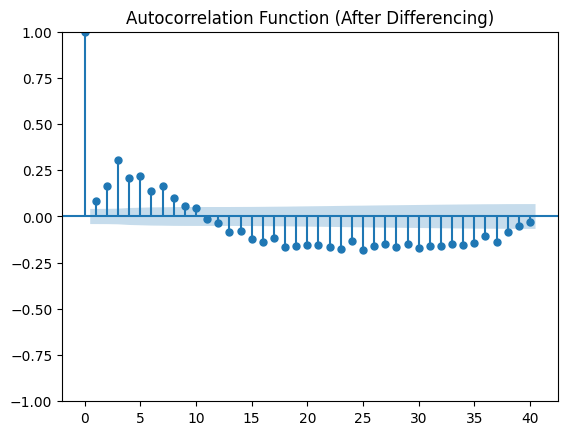

<Figure size 1400x700 with 0 Axes>

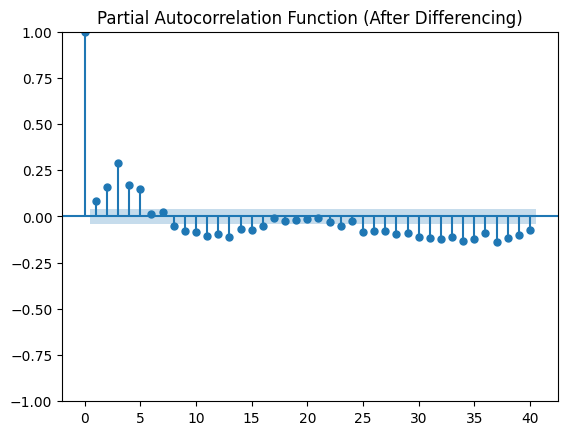

In [11]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Perform differencing to make the data stationary if it wasn't already
diff_data = data['co2'].diff().dropna()

# Plot the Autocorrelation Function (ACF) for the differenced data
plt.figure(figsize=(14, 7))  # Set the size of the plot
plot_acf(diff_data, lags=40, alpha=0.05)  # Plot ACF with 40 lags and 95% confidence interval
plt.title('Autocorrelation Function (After Differencing)')  # Set the title of the plot
plt.show()  # Display the plot

# Plot the Partial Autocorrelation Function (PACF) for the differenced data
plt.figure(figsize=(14, 7))  # Set the size of the plot
plot_pacf(diff_data, lags=40, alpha=0.05, method='ywm')  # Plot PACF with 40 lags and 95% confidence interval
plt.title('Partial Autocorrelation Function (After Differencing)')  # Set the title of the plot
plt.show()  # Display the plot


## Autocorrelation and Partial Autocorrelation Analysis for Time Series Data

### Overview
This analyzes the autocorrelation and partial autocorrelation of a time series dataset after differencing, which is a critical step in understanding the data dependencies for modeling, especially for ARIMA model estimation.

### Detailed Code Explanation

#### Setup and Differencing
- **Differencing the Data:**
  - `diff_data = data['co2'].diff().dropna()`: Differencing is performed on the 'co2' data to ensure stationarity, which is crucial for accurate autocorrelation and partial autocorrelation analysis. The `diff()` method calculates the difference between consecutive observations, and `dropna()` removes any resulting NaN values which occur from the differencing.

#### Autocorrelation Function (ACF)
- **Plotting ACF:**
  - `plt.figure(figsize=(14, 7))`: Initializes a new figure for plotting with a specified size.
  - `plot_acf(diff_data, lags=40, alpha=0.05)`: Uses the `plot_acf` function to compute and plot the autocorrelation function for 40 lags. The `alpha` parameter specifies the confidence interval (here, 95% confidence).
  - `plt.title(...)`: Adds a title to the ACF plot.
  - `plt.show()`: Displays the ACF plot.

#### Partial Autocorrelation Function (PACF)
- **Plotting PACF:**
  - `plt.figure(figsize=(14, 7))`: Similar to ACF, initializes a figure for the PACF plot.
  - `plot_pacf(diff_data, lags=40, alpha=0.05, method='ywm')`: Computes and plots the partial autocorrelation function using the `plot_pacf` function. The 'ywm' method is specified for the PACF calculation, which uses the Yule-Walker method with bias correction.
  - `plt.title(...)`: Sets the title for the PACF plot.
  - `plt.show()`: Renders the PACF plot.


ACF and PACF plots are instrumental in identifying the order of the autoregressive (AR) and moving average (MA) processes in ARIMA modeling. ACF shows the total correlation between different lags, while PACF shows the correlation that isn't accounted for by earlier lags, thus helping in selecting the appropriate p and q values for ARIMA models.

Suggested Model Parameters:

    AR order (p): The PACF suggests p=3 or 4. This is based on the sharp cut-off after the fourth lag, indicating that the autoregressive part of the ARIMA model should be set to 4.
    
    MA order (q): From the ACF plot, you might consider q=7 or q=8 because the autocorrelations are significant at the seven or eight of lags and then begin to diminish, but still show some influence. The exact choice between q=7 or q=8 can depend on additional model diagnostics like AIC/BIC values during the model fitting process.

## Application of ARIMA Model

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm

# Ensure the time series index is set properly
data.index = pd.to_datetime(data.index)  # Convert the index to datetime, ensuring proper time series handling
data = data.asfreq('W-SAT')  # Set the frequency of the data to weekly, ending on Saturday

# Split the data into training and test sets
train_set = data['co2'][:-50]  # Use all data except the last 50 weeks for training
test_set = data['co2'][-50:]  # Use the last 50 weeks for testing

# Fitting the ARIMA model
try:
    model = ARIMA(train_set, order=(4, 1, 7), trend='n')  # Fit an ARIMA model with specified order and no trend
    model_fit = model.fit()  # Fit the model
    print(model_fit.summary())  # Print the model summary
except Exception as e:
    print("Error in fitting the model:", e)  # Print any errors during model fitting

# Forecasting
n_periods = len(test_set)  # Define the number of periods to forecast
try:
    forecast_results = model_fit.get_forecast(steps=n_periods)  # Forecast the future values
    y_predicted = forecast_results.predicted_mean  # Extract the predicted means from the forecast
    conf_int = forecast_results.conf_int()  # Extract the confidence intervals from the forecast
except Exception as e:
    print("Error in forecasting:", e)  # Print any errors during forecasting

# Enhanced focus on transition from training to prediction
transition_points = train_set[-50:]  # Extract the last 50 points of the training set to show transition

# Plotting with enhanced focus
plt.figure(figsize=(12, 6))  # Create a figure for plotting
plt.plot(transition_points.index, transition_points, label='Training Data', color='blue', alpha=0.6)  # Plot the transition points
plt.plot(test_set.index, test_set, label='Actual CO2 Levels', color='green', alpha=0.6)  # Plot the actual test data
forecast_index = pd.date_range(start=train_set.index[-1], periods=n_periods + 1, freq='W-SAT')[1:]  # Define the forecast index
plt.plot(forecast_index, y_predicted, label='Predicted CO2 Levels', color='red', linestyle='--')  # Plot the predicted values
plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')  # Plot the confidence intervals
plt.title('Focused ARIMA CO2 Level Prediction Transition')  # Set the plot title
plt.xlabel('Date')  # Set the x-axis label
plt.ylabel('CO2 Levels')  # Set the y-axis label
plt.legend(loc='upper left')  # Place the legend in the upper left corner
plt.grid(True)  # Enable the grid
plt.tight_layout()  # Adjust the layout
plt.show()  # Display the plot


## ARIMA Model Fitting and Forecasting for CO2 Levels

### Overview
This fits an ARIMA model to the weekly CO2 data from the Mauna Loa Observatory to predict future levels, enhancing the focus on the transition from historical data to predictions.

### Detailed Code Explanation

#### Preprocessing and Setup
- **Datetime Conversion and Frequency Setting:**
  - `data.index = pd.to_datetime(data.index)`: Ensures the time series index is in the proper datetime format for time series analysis.
  - `data = data.asfreq('W-SAT')`: Sets the data frequency to weekly, ending on Saturday, aligning the data points with a consistent weekly cycle.

#### Data Partitioning
- **Splitting Data:**
  - `train_set = data['co2'][:-50]`: Segregates the dataset into a training set, excluding the last 50 observations to be used as a test set.
  - `test_set = data['co2'][-50:]`: Defines the test set comprising the last 50 weeks of data.

#### ARIMA Modeling
- **Model Fitting:**
  - `model = ARIMA(train_set, order=(4, 1, 7), trend='n')`: Instantiates an ARIMA model with specific orders for autoregression (4), differencing (1), and moving average (7) components, and specifies no trend component in the model.
  - `model_fit = model.fit()`: Fits the ARIMA model to the training data.
  - `print(model_fit.summary())`: Outputs a summary of the fitted model, providing details on the coefficients and diagnostics.

#### Forecasting
- **Generating Forecasts:**
  - `forecast_results = model_fit.get_forecast(steps=n_periods)`: Performs forecasting over the defined number of periods matching the test set size.
  - `y_predicted = forecast_results.predicted_mean`: Extracts the mean values of the forecasted periods.
  - `conf_int = forecast_results.conf_int()`: Retrieves the confidence intervals for the forecasts, giving an estimate of the uncertainty.

#### Visualization
- **Focused Transition Plotting:**
  - `transition_points = train_set[-50:]`: Captures the last 50 points of the training data to illustrate the transition from training to prediction visually.
  - Plots are constructed using `matplotlib.pyplot`, showing training data, actual test data, predicted values, and confidence intervals with appropriate labels and legends to distinguish the data series.

### Usage
This  is particularly useful for time series forecasting where historical data trends and future predictions are critical, such as in environmental data analysis for CO2 levels, which has implications for climate policy and scientific research.

## Future Work Suggestions for ARIMA Modeling of CO2 Levels

### Enhanced Model Tuning
- **Hyperparameter Optimization**: Explore more advanced techniques for parameter tuning, such as grid search or Bayesian optimization methods, to find the optimal model configurations beyond what `auto_arima` provides.
- **Cross-Validation**: Implement time series cross-validation to assess model stability and performance across different time splits, ensuring robustness in forecasts.

### Model Extensions
- **Incorporate Exogenous Variables**: Consider integrating other environmental or temporal variables that could impact CO2 levels, such as temperature, industrial activity levels, or global policy changes.
- **Hybrid Models**: Experiment with hybrid approaches that combine ARIMA with machine learning models like random forests or neural networks like LSTM to capture nonlinear relationships and improve forecast accuracy.

### Data Enrichment
- **Longer Time Series**: If available, extend the dataset to cover more decades to better understand long-term trends and cyclic patterns.
- **Higher Frequency Data**: Utilize higher resolution data, such as daily measurements, to capture more granular trends and anomalies in CO2 levels.

### Computational Enhancements
- **Parallel Computing**: Leverage parallel computing resources to reduce the computation time for parameter tuning and model fitting, especially when scaling to larger datasets or more complex models.
- **Cloud-based Analytics**: Utilize cloud computing platforms for data storage and computation to enhance scalability and collaboration across different geographic locations.

### Visualization Improvements
- **Interactive Dashboards**: Develop interactive dashboards using tools like Plotly or Bokeh, allowing users to explore different forecast scenarios dynamically and adjust parameters on the fly.
- **Geospatial Analysis**: Incorporate geospatial visualizations to explore CO2 distributions and impacts at a more localized level, potentially integrating satellite data.

### Statistical Analysis Expansion
- **Uncertainty Analysis**: Deepen the analysis of forecast uncertainty, possibly incorporating Bayesian methods to provide more informative confidence intervals.
- **Seasonal Adjustments**: Refine the seasonal adjustment processes, exploring different methods or custom adjustments tailored to specific environmental phenomena influencing CO2 trends.